In [1]:
print('hi')

hi


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# 1. Load the cleaned data
df = pd.read_csv('../data/processed/final.csv')


In [5]:
df.head()

,SWEAT index,K index,Totals totals index,Environmental Stability,Moisture Indices,Convective Potential,Temperature Pressure,Moisture Temperature Profiles,target
0,91.2,-1.4,24.7,25.8,22.8,0.0,5636,993.98,0
1,75.7,1.6,30.3,21.5,20.4,0.0,5592,956.13,0
2,128.3,17.5,41.6,13.8,23.8,0.0,5581,978.71,0
3,194.2,23.5,50.6,4.0,28.6,-55.4,5578,965.77,0
4,151.4,25.4,43.8,6.9,33.2,-65.0,5648,975.72,0


In [6]:
# 2. Split Features and Target
X = df.drop('target', axis=1)
y = df['target']

In [7]:
# 3. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Save it!
joblib.dump(scaler, '../models/scaler.joblib')


['../models/scaler.joblib']

In [7]:
# 4. Handle Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [8]:
# 5. Define Scientific Metrics Function
def get_weather_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0
    far = fp / (fp + tp) if (fp + tp) > 0 else 0
    csi = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    return {"POD": pod, "FAR": far, "CSI": csi}


In [10]:
# 6. The Model Contest
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}
comparison_results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    
    # Get metrics
    res = get_weather_metrics(y_test, y_pred)
    res["Model"] = name
    comparison_results.append(res)


Training Random Forest...
Training XGBoost...
Training SVM...


In [11]:
# 7. Display Results
df_results = pd.DataFrame(comparison_results).set_index("Model")
print("\n--- The Results ---")
display(df_results)


--- The Results ---


,POD,FAR,CSI
Model,,,
Random Forest,0.629167,0.609819,0.317227
XGBoost,0.745833,0.621964,0.334892
SVM,0.885417,0.658085,0.327427


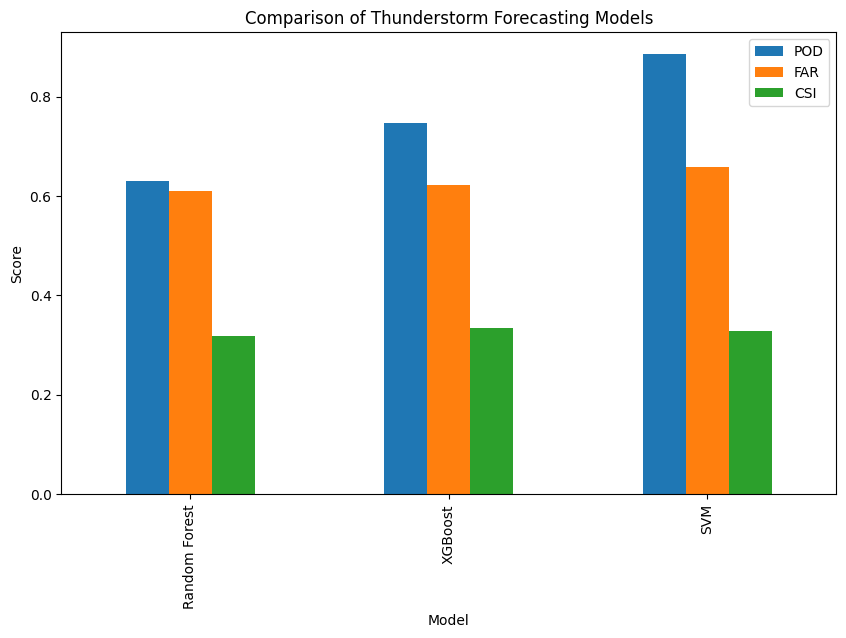

In [12]:
# 8. Visualization
df_results.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Thunderstorm Forecasting Models')
plt.ylabel('Score')
plt.show()

In [13]:
import joblib 
import os
best_model=models["XGBoost"]
joblib.dump(best_model,'../models/xgboost_model.joblib')
print('Success')

Success
